# Load and display the Bagpipes vs Prospector comparisons!

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import pandas as pd
import os
import h5py
from corner import quantile
from astropy.cosmology import WMAP9 as cosmo

import scipy
import numpy as np
import astropy
import scipy.stats as stats
from scipy.stats import binned_statistic

no_spec = [9517, 9809, 11051, 11451, 12133, 17713, 17984, 20195, 20693, 20720, 21472, 22990]
bl_agn = [12020, 18977]
intermediate_ap = [7136, 1904, 7922, 8469, 10314, 11337, 11420, 11451, 17517, 17669, 18332, 21452]

exclude = no_spec + bl_agn + intermediate_ap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Function to read the Prospector output files

In [73]:
prosp_dir = '/Users/benjamincollins/Data/Bluejay/Prospector/v2.3/sourcephotonly_wMIRI/'

example_id = 7102

def load_prospector_results(galaxy_id, prosp_dir):
    """Function to load Prospector result .h5 files and disect its 
    data structure to be used for easy plotting.

    Args:
        galaxy_id (int): The ID of the galaxy for which to load results
        prosp_dir (str): The directory containing the Prospector output files

    Returns:
        _type_: _description_
    """
    
    file = glob.glob(os.path.join(prosp_dir, f'*{galaxy_id}*.h5'))[0]
    
    print(f"Loading Prospector output file: {file}")
    
    with h5py.File(file, 'r') as f:
        # Step 1: Extract the model parameters from the file attributes and display in human-readable format
        model_params = pkl.loads(f.attrs['model_params'], encoding='latin1')
        
        # Step 2: Extract the sampling results (chain and weights)
        chain = f['sampling']['chain'][:]
        lnlikelihood = f['sampling']['lnlikelihood'][:]

        # Step 3: Get maximum likelihood index
        imax = np.argmax(lnlikelihood)
            
        # there must be a more elegant way to deal with differnt shapes
        try:
            i, j = np.unravel_index(imax, lnlikelihood.shape)
            theta_best = chain[i, j, :].copy()
        except(ValueError):
            theta_best = chain[imax, :].copy()

        weights = f['sampling']['weights'][:] if 'weights' in f['sampling'] else None
        
        # Extract labels for parameters that were "free" (fitted)
        labels = [p['name'] for p in model_params if p.get('isfree', False)]    
        
        # 4. Build the data structure
        results = {
            'meta': {'labels': labels, 'map_idx': imax, 'weights': weights},
            'params': {}
        }
        
        for i, name in enumerate(labels):
                samples = chain[:, i]
                q16, q50, q84 = quantile(samples, [0.16, 0.5, 0.84], weights=weights)
                
                results['params'][name] = {
                    'samples': samples,
                    'map': samples[imax],
                    'q50': q50,
                    'q84': q84,
                    'q16': q16
                }

        return results

example_res = load_prospector_results(example_id, prosp_dir)
print(example_res)

# Map labels to their index for easy access
#p_dict = {label: chain[:, i] for i, label in enumerate(labels)}

#print("Your Prospector Parameter Labels are:")
#print(p_dict)

# Get 16th, 50th, and 84th percentiles
# 'weights' is from f['weights'][:]
#q_16, q_50, q_84 = quantile(p_dict['logmass'], [0.16, 0.5, 0.84], weights=weights)

#print(f"Log Mass: {q_50:.2f} (+{q_84-q_50:.2f} / -{q_50-q_16:.2f})")
#print(f"Log Mass: {theta_best[labels.index('logmass')]:.2f} (+{q_84-q_50:.2f} / -{q_50-q_16:.2f})")

Loading Prospector output file: /Users/benjamincollins/Data/Bluejay/Prospector/v2.3/sourcephotonly_wMIRI/output_7102_onlyphot_wMIRI_mcmc.h5
{'meta': {'labels': ['zred', 'logzsol', 'f_outlier_phot', 'logmass', 'logsfr_ratios', 'dust2', 'dust_index', 'dust1_fraction', 'duste_umin', 'duste_qpah', 'duste_gamma', 'gas_logz', 'gas_logu'], 'map_idx': np.int64(82786), 'weights': array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       3.01388710e-06, 3.03428264e-06, 3.18663735e-06], shape=(82787,))}, 'params': {'zred': {'samples': array([3.25772523, 3.26548872, 3.26639708, ..., 3.26342166, 3.26389124,
       3.26323782], shape=(82787,)), 'map': np.float64(3.2632378179383297), 'q50': 3.262953759062853, 'q84': 3.2635268207677184, 'q16': 3.262493690529052}, 'logzsol': {'samples': array([-0.68869733,  0.43902821,  0.22788704, ..., -1.7347934 ,
       -1.84810777, -1.74223319], shape=(82787,)), 'map': np.float64(-1.7422331915670073), 'q50': -1.794820201796468, 'q84': -1.5284875625751255, 

Function to read the Bagpipes output files

In [97]:
bagp_dir = '/Users/benjamincollins/University/PhD/Code/bagpipes/BlueJay/pipes/posterior/fesc_with_miri/'

from astropy.io import fits
from astropy.table import Table

import bagpipes as pipes

def load_bluejay(ID):
    """ Load BlueJay photometry from the BlueJay catalogue(s)"""

    # Blue Jay catalogue
    bluejay_cat = Table.read("bluejay_phot_cat_v1.4.fits")
    
    # 1. List all available HST/NIRCam bands:
    filters = ['F090W', 'F115W', 'F125W', 'F140W', 'F150W', 'F160W', 
               'F200W', 'F277W', 'F356W', 'F410M', 'F444W', 'F606W', 'F814W']
    
    # 2. Find the correct row using the ID column
    # Use a mask rather than (int(ID) - 1) to be safe against non-sequential IDs
    row = bluejay_cat[bluejay_cat['ID'] == int(ID)]

    if len(row) == 0:
        raise ValueError(f"ID {ID} not found in catalogue.")
    
    # 3. Extract fluxes and errors into lists
    fluxes = []
    flux_errs = []

    for f in filters:
        fluxes.append(row[f + "_flux"][0] * 1e6)
        flux_errs.append(row[f + "_flux_err"][0] * 1e6)


    # MIRI catalogue
    miri_cat = Table.read("Phot_Table_MIRI.fits")
    
    # 1. List all available MIRI bands:
    miri_filters = ['F770W', 'F1000W', 'F1800W', 'F2100W']
    
    # 2. Find the correct row using the ID column
    # Use a mask rather than (int(ID) - 1) to be safe against non-sequential IDs
    row = miri_cat[miri_cat['ID'] == int(ID)]

    if len(row) == 0:
        raise ValueError(f"ID {ID} not found in catalogue.")
    
    # 3. Extract fluxes and errors into lists
    for f in miri_filters:
        fluxes.append(row[f + "_flux"][0] * 1e6)
        flux_errs.append(row[f + "_flux_err"][0] * 1e6)
    
    # Now turn these into a 2D array [N_filters, 2]
    # Bagpipes expects photometry[i, 0] = flux, photometry[i, 1] = error
    photometry = np.c_[fluxes, flux_errs]
    
    # 5. Clean up missing data and enforce SNR limits
    for i in range(len(photometry)):
        # Blow up errors for missing data (NaN or 0 flux)
        if (photometry[i, 0] <= 0.) or (np.isnan(photometry[i, 0])):
            photometry[i, :] = [0., 9.9e99]
            continue # Skip SNR check for bad data
    
    return photometry

# Redshift
def get_zred(galaxy_id):    
    # --- Read Blue Jay catalogue ---
    blue = "/Users/benjamincollins/University/PhD/Code/bagpipes/BlueJay/BlueJay_sample.txt"
    tbl = Table.read(blue, format="ascii.basic")
    
    row = tbl[tbl['id'] == int(galaxy_id)]
    
    # Make sure that the code doesn't crash if it can't find the ID in the catalogue
    if len(row) == 0:   
        return None, False
    
    z_spec = row['z_spec'][0]
    
    if z_spec is not None and not np.isnan(z_spec):
        return z_spec, True
    else:
        z_phot = row['z_phot'][0]
        return z_phot, False

# Star formation histories
def zred_to_agebins(zred, z_limit_sfh=20.0, nbins_sfh=8):
    tuniv = cosmo.age(zred).value*1e9   # Age of the universe at the observed redshift in years
    #tbinmax = tuniv-cosmo.age(z_limit_sfh).value*1e9 # Maximum age bin edge corresponding to z_limit_sfh
    tbinmax = tuniv*0.95
    # Compute edges in logarithmic space
    log_edges = np.append(np.array([0.0, 6.7, 7.0]), np.linspace(7.0, np.log10(tbinmax), int(nbins_sfh-1))[1:])
    bin_edges = 10**log_edges   # Convert back to linear space
    bin_edges /= 1e6 # ensure that edges are in Myr for Bagpipes
    return bin_edges.tolist()   # return list of age bin edges

In [56]:
run = "no_fesc_with_miri"

posterior_dir = f'/Users/benjamincollins/University/PhD/Code/bagpipes/BlueJay/pipes/posterior/{run}'

filename = os.path.join(posterior_dir, f"{objid}.h5")

# Create galaxy object for the current ID
galaxy = pipes.galaxy(f"{objid}", load_bluejay, spectrum_exists=False, filt_list=bluejay_filt_list)

# Load the redshift
zred, is_spectroscopic = get_zred(objid)

if is_spectroscopic:
    print(f"Fixing redshift to the spectroscopic value of the source: {zred}")
    fit_instructions["redshift"] = zred                       # Fix the redshift to the spectroscopic value to reduce runtime
else:
    print(f"Using photometric redshift of {zred} with a Gaussian prior for the source.")
    fit_instructions["redshift"] = (zred-0.25, zred+0.25)     # Set the redshift prior to vary within +/1 of the photometric redshift
    fit_instructions["redshift_prior"] = "Gaussian"           # Use a Gaussian prior
    fit_instructions["redshift_prior_mu"] = zred              # Centred on the photometric redshift
    fit_instructions["redshift_prior_sigma"] = 0.05           # With a width of 0.05

# Calculate the agebins for the star formation history of the galaxy based on its redshift and update the fit instructions
age_bins = zred_to_agebins(zred, nbins_sfh=7)
print("Age bins:", age_bins)
fit_instructions["continuity"]["bin_edges"] = age_bins   

fit = pipes.fit(galaxy, fit_instructions, run=run)

fit.fit(verbose=True, sampler='nautilus', pool=6, discard_exploration=True)

Fixing redshift to the spectroscopic value of the source: 3.265
Age bins: [1e-06, 5.011872336272725, 10.0, 28.503361672054368, 81.2441626607938, 231.57317520638213, 660.0613966453524, 1881.3968714343814]

Results loaded from pipes/posterior/no_fesc_with_miri/7102.h5

Fitting not performed as results have already been loaded from pipes/posterior/no_fesc_with_miri/7102.h5. To start over delete this file or change run.



In [57]:
print(type(fit.results["lnlike"]), len(fit.results["lnlike"]))

<class 'numpy.ndarray'> 508


In [58]:
max_like_index = np.argmax(fit.results["lnlike"])
print(max_like_index)

217


In [59]:
print(fit.results.keys())
print(fit.fitted_model.params)

print(fit.results["samples2d"][max_like_index, :])

dict_keys(['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d'])
['continuity:dsfr1', 'continuity:dsfr2', 'continuity:dsfr3', 'continuity:dsfr4', 'continuity:dsfr5', 'continuity:dsfr6', 'continuity:massformed', 'continuity:metallicity', 'dust:Av', 'dust:gamma', 'dust:n', 'dust:qpah', 'dust:umin', 'nebular:logU']
[ 1.01633688e+00  5.94339122e-01  4.59186483e-01 -4.39340480e-02
  2.12044581e-03  3.90084952e-01  9.90627701e+00  1.07576959e-01
  2.35193439e+00  9.79076073e-01  2.61414097e-01  4.18511057e+00
  1.60905915e+01 -1.00546970e+00]


In [60]:
fit.fitted_model._update_model_components(fit.results["samples2d"][max_like_index, :])

max_like_model_components = fit.fitted_model.model_components

print(max_like_model_components)

{'dust': {'type': 'CF00', 'Av': np.float64(2.3519343856641197), 'n': np.float64(0.26141409687724626), 'n_prior': 'Gaussian', 'n_prior_mu': 0.7, 'n_prior_sigma': 0.3, 'qpah': np.float64(4.185110570645108), 'umin': np.float64(16.090591467062563), 'gamma': np.float64(0.9790760733552035)}, 'nebular': {'logU': np.float64(-1.005469700326877)}, 'continuity': {'massformed': np.float64(9.906277008161048), 'metallicity': np.float64(0.10757695905440574), 'metallicity_prior': 'log_10', 'dsfr1': np.float64(1.0163368847708973), 'dsfr1_prior': 'student_t', 'dsfr2': np.float64(0.594339122301233), 'dsfr2_prior': 'student_t', 'dsfr3': np.float64(0.4591864827015473), 'dsfr3_prior': 'student_t', 'dsfr4': np.float64(-0.043934047982724427), 'dsfr4_prior': 'student_t', 'dsfr5': np.float64(0.002120445812948029), 'dsfr5_prior': 'student_t', 'dsfr6': np.float64(0.39008495153348405), 'dsfr6_prior': 'student_t', 'bin_edges': [1e-06, 5.011872336272725, 10.0, 28.503361672054368, 81.2441626607938, 231.57317520638213

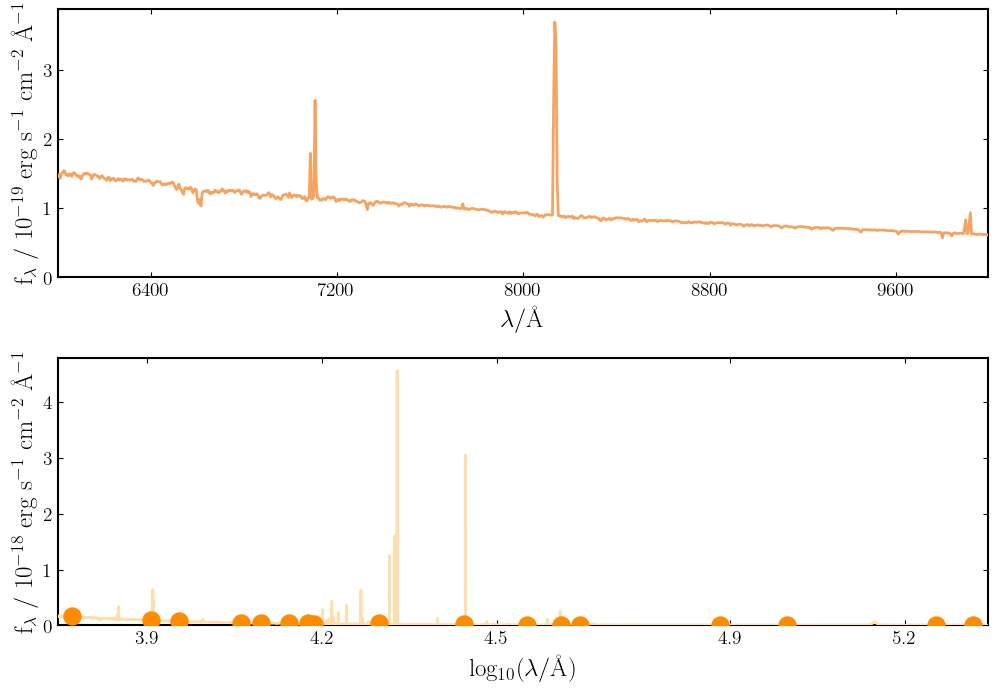

In [61]:
max_like_model_galaxy = pipes.model_galaxy(max_like_model_components,
                                           filt_list=bluejay_filt_list,
                                           spec_wavs=np.arange(6000., 10000., 5.))

fig = max_like_model_galaxy.plot()

There must be more information hidden somewhere!

In [70]:
list(fit.posterior.samples['stellar_mass'])[max_like_index]
print(len(fit.posterior.samples['stellar_mass']))

500


# Code to extract data from the bagpipes output files

In [ ]:
run = 'fesc_with_miri/'

example_id = 7102

def load_bagpipes_results(galaxy_id, run):
    """Function to load Bagpipes result .h5 files and disect its 
    data structure to be used for easy plotting.

    Args:
        galaxy_id (int): The ID of the galaxy for which to load results
        run (str): The run identifier for the Bagpipes output files

    Returns:
        _type_: _description_
    """
    
    bluejay_filt_list = np.loadtxt("filters/bluejay_filt_list.txt", dtype="str")

    galaxy = pipes.galaxy(f"{galaxy_id}", load_bluejay, spectrum_exists=False, filt_list=bluejay_filt_list)
    
    fit_instructions = {}                       # The fit instructions dictionary

    # Nebular component
    nebular = {}
    nebular["logU"] = (-4., -1.)                # Log_10 of the ionisation parameter.
    #nebular["fesc"] = (0., 1.)                  # IMPORTANT: Escape fraction of ionising photons. Standard value is 0.1

    # Dust absorption parameters
    dust = {}                               # Dust component
    dust["type"] = "CF00"                   # Define the shape of the attenuation curve
    dust["Av"] = (0., 4.0)                  # Vary Av between 0 and 3.2 magnitudes
    dust["n"] = (-1.0, 1.5)                 # Vary the slope of the attenuation curve from -1.0 to 1.5
    dust["n_prior"] = "Gaussian"            # Set a Gaussian prior
    dust["n_prior_mu"] = 0.7                # Centred on the standard CF00 slope of 0.7
    dust["n_prior_sigma"] = 0.3             # With a width of 0.3

    # Dust emission parameters (now free parameters)
    dust["qpah"] = (0.1, 4.58)                  # PAH mass fraction (spanning the entire grid)
    dust["umin"] = (0.1, 25.)                   # Lower limit of starlight intensity distribution (spanning the entire grid)
    dust["gamma"] = (0., 1.0)                   # Fraction of stars at Umin

    # Setting the SFH priors
    continuity = {}
    continuity["massformed"] = (8.5, 13)            # Log10 of solar mass formed
    continuity["metallicity"] = (0.01, 3.16)        # Linear Z/Z_solar: 0.01 to 3.16
    continuity["metallicity_prior"] = "log_10"      # Logarithmic prior for metallicity

    # Define the dsfr ratios
    for i in range(1, 7):   # for 7 bins
        continuity[f"dsfr{i}"] = (-10., 10.) 
        continuity[f"dsfr{i}_prior"] = "student_t"
        #continuity["dsfr" + str(i) + "_prior_df"] = 2       # Default nu value of 2 in the student_t distribution
        #continuity["dsfr" + str(i) + "_prior_scale"] = 0.3  # Default sigma value of 0.3 in the student_t distribution

    fit_instructions["dust"] = dust
    fit_instructions["nebular"] = nebular
    fit_instructions["continuity"] = continuity
        
    # Load the redshift
    zred, is_spectroscopic = get_zred(galaxy_id)

    if is_spectroscopic:
        fit_instructions["redshift"] = zred        # Fix the redshift to the spectroscopic value to reduce runtime
    else:
        print(f"Wait what? I thought we were only using spectroscopically confirmed sources? Abort.")
        return None

    # Calculate the agebins for the star formation history of the galaxy based on its redshift and update the fit instructions
    age_bins = zred_to_agebins(zred, nbins_sfh=7)
    fit_instructions["continuity"]["bin_edges"] = age_bins   

    fit = pipes.fit(galaxy, fit_instructions, run=run)
        
    # Get maximum likelihood index
    imax = np.argmax(fit.results["lnlike"])
    
    labels = fit.posterior.samples.keys()
    
    results = {
            'meta': {'labels': labels, 'map_idx': imax, 'weights': None},
            'params': {}
    }
    
    for i, name in enumerate(labels):
        samples = fit.posterior.samples[name]
        q16, q50, q84 = quantile(samples, [0.16, 0.5, 0.85], weights=None)
        
        results['params'][name] = {
                    'samples': samples,
                    'map': samples[imax],
                    'q50': q50,
                    'q84': q84,
                    'q16': q16
                }
            
    return results
    
res = load_bagpipes_results(7102, run='fesc_with_miri')


Results loaded from pipes/posterior/fesc_with_miri/7102.h5

dict_keys(['meta', 'params'])
